In [1]:
!pip install pyjanitor
import janitor

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 215.4/215.4 kB 3.8 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
sns.set(style='whitegrid',context='notebook')

In [5]:
df = pd.read_csv('/content/car_price_prediction.csv')
df

,ID,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags
0,45654403,13328,1399,LEXUS,RX 450,2010,Jeep,Yes,Hybrid,3.5,186005 km,6.0,Automatic,4x4,04-May,Left wheel,Silver,12
1,44731507,16621,1018,CHEVROLET,Equinox,2011,Jeep,No,Petrol,3,192000 km,6.0,Tiptronic,4x4,04-May,Left wheel,Black,8
2,45774419,8467,-,HONDA,FIT,2006,Hatchback,No,Petrol,1.3,200000 km,4.0,Variator,Front,04-May,Right-hand drive,Black,2
3,45769185,3607,862,FORD,Escape,2011,Jeep,Yes,Hybrid,2.5,168966 km,4.0,Automatic,4x4,04-May,Left wheel,White,0
4,45809263,11726,446,HONDA,FIT,2014,Hatchback,Yes,Petrol,1.3,91901 km,4.0,Automatic,Front,04-May,Left wheel,Silver,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19232,45798355,8467,-,MERCEDES-BENZ,CLK 200,1999,Coupe,Yes,CNG,2.0 Turbo,300000 km,4.0,Manual,Rear,02-Mar,Left wheel,Silver,5
19233,45778856,15681,831,HYUNDAI,Sonata,2011,Sedan,Yes,Petrol,2.4,161600 km,4.0,Tiptronic,Front,04-May,Left wheel,Red,8
19234,45804997,26108,836,HYUNDAI,Tucson,2010,Jeep,Yes,Diesel,2,116365 km,4.0,Automatic,Front,04-May,Left wheel,Grey,4
19235,45793526,5331,1288,CHEVROLET,Captiva,2007,Jeep,Yes,Diesel,2,51258 km,4.0,Automatic,Front,04-May,Left wheel,Black,4


In [6]:
df = df.clean_names()
df

,id,price,levy,manufacturer,model,prod_year,category,leather_interior,fuel_type,engine_volume,mileage,cylinders,gear_box_type,drive_wheels,doors,wheel,color,airbags
0,45654403,13328,1399,LEXUS,RX 450,2010,Jeep,Yes,Hybrid,3.5,186005 km,6.0,Automatic,4x4,04-May,Left wheel,Silver,12
1,44731507,16621,1018,CHEVROLET,Equinox,2011,Jeep,No,Petrol,3,192000 km,6.0,Tiptronic,4x4,04-May,Left wheel,Black,8
2,45774419,8467,-,HONDA,FIT,2006,Hatchback,No,Petrol,1.3,200000 km,4.0,Variator,Front,04-May,Right-hand drive,Black,2
3,45769185,3607,862,FORD,Escape,2011,Jeep,Yes,Hybrid,2.5,168966 km,4.0,Automatic,4x4,04-May,Left wheel,White,0
4,45809263,11726,446,HONDA,FIT,2014,Hatchback,Yes,Petrol,1.3,91901 km,4.0,Automatic,Front,04-May,Left wheel,Silver,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19232,45798355,8467,-,MERCEDES-BENZ,CLK 200,1999,Coupe,Yes,CNG,2.0 Turbo,300000 km,4.0,Manual,Rear,02-Mar,Left wheel,Silver,5
19233,45778856,15681,831,HYUNDAI,Sonata,2011,Sedan,Yes,Petrol,2.4,161600 km,4.0,Tiptronic,Front,04-May,Left wheel,Red,8
19234,45804997,26108,836,HYUNDAI,Tucson,2010,Jeep,Yes,Diesel,2,116365 km,4.0,Automatic,Front,04-May,Left wheel,Grey,4
19235,45793526,5331,1288,CHEVROLET,Captiva,2007,Jeep,Yes,Diesel,2,51258 km,4.0,Automatic,Front,04-May,Left wheel,Black,4


# EDA

In [7]:
df.dtypes.value_counts()

,count
object,13
int64,4
float64,1


In [8]:
df.isna().sum().sum()

np.int64(0)

In [9]:
df.columns

Index(['id', 'price', 'levy', 'manufacturer', 'model', 'prod_year', 'category',
       'leather_interior', 'fuel_type', 'engine_volume', 'mileage',
       'cylinders', 'gear_box_type', 'drive_wheels', 'doors', 'wheel', 'color',
       'airbags'],
      dtype='object')

In [10]:
df_clean = df.select_dtypes(include='number').copy()
df_clean.drop(columns=['id'],inplace=True)
df_clean

,price,prod_year,cylinders,airbags
0,13328,2010,6.0,12
1,16621,2011,6.0,8
2,8467,2006,4.0,2
3,3607,2011,4.0,0
4,11726,2014,4.0,4
...,...,...,...,...
19232,8467,1999,4.0,5
19233,15681,2011,4.0,8
19234,26108,2010,4.0,4
19235,5331,2007,4.0,4


# CORRELACIONES

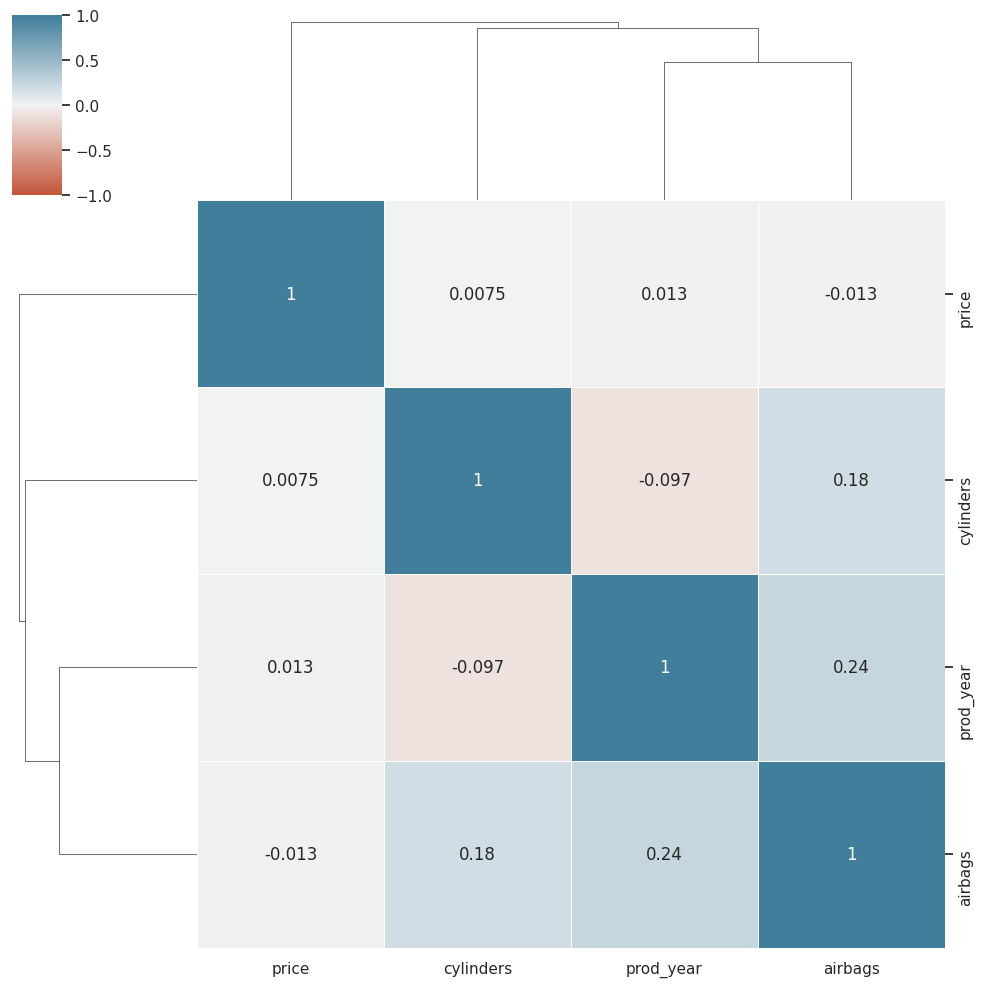

In [11]:
sns.clustermap(
    data=df_clean.corr(numeric_only=True),
    cmap=sns.diverging_palette(20,230,as_cmap=True),
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    cbar_kws={'shrink':0.5},
    annot=True
)

# ESCALAMIENTO DE DATOS

In [12]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [13]:
X = df[['cylinders','prod_year']].values
y = df[['price']].values

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.20)

In [14]:
sc_x = StandardScaler()
X_train = sc_x.fit_transform(X_train)
X_test = sc_x.fit_transform(X_test)

sc_y = StandardScaler()
y_train = sc_y.fit_transform(y_train)
y_test = sc_y.fit_transform(y_test)

# EVALUAMOS LOS MODELOS

In [15]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.neural_network import MLPRegressor

In [16]:
# Definir modelos de regresión
modelos = {
    "Regresión Lineal": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.1),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42),
    "SVR": SVR(kernel='rbf'),
    "XGBoost": XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42),
    "Red Neuronal (MLP)": MLPRegressor(hidden_layer_sizes=(100, ), activation='relu', solver='adam',
                                        max_iter=500, random_state=42)
}

# Evaluar cada modelo
def evaluar_modelo(modelo, nombre):
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    print(f'\n{nombre}:')
    print(f'Error Cuadrático Medio (MSE): {mse:.4f}')
    print(f'Coeficiente de Determinación (R²): {r2:.4f}')
    return r2

# Comparar modelos
resultados = {}
for nombre, modelo in modelos.items():
    resultados[nombre] = evaluar_modelo(modelo, nombre)

# Mostrar el mejor modelo
mejor_modelo = max(resultados, key=resultados.get)
print(f'\nEl mejor modelo es: {mejor_modelo} con un R² de {resultados[mejor_modelo]:.4f}')



Regresión Lineal:
Error Cuadrático Medio (MSE): 0.9946
Coeficiente de Determinación (R²): 0.0054

Ridge:
Error Cuadrático Medio (MSE): 0.9946
Coeficiente de Determinación (R²): 0.0054

Lasso:
Error Cuadrático Medio (MSE): 1.0000
Coeficiente de Determinación (R²): -0.0000


/usr/local/lib/python3.11/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)



Random Forest:
Error Cuadrático Medio (MSE): 0.9905
Coeficiente de Determinación (R²): 0.0095


/usr/local/lib/python3.11/dist-packages/sklearn/ensemble/_gb.py:672: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)  # TODO: Is this still required?



Gradient Boosting:
Error Cuadrático Medio (MSE): 0.9901
Coeficiente de Determinación (R²): 0.0099


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)



SVR:
Error Cuadrático Medio (MSE): 0.9945
Coeficiente de Determinación (R²): 0.0055

XGBoost:
Error Cuadrático Medio (MSE): 0.9963
Coeficiente de Determinación (R²): 0.0037


/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:1650: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)



Red Neuronal (MLP):
Error Cuadrático Medio (MSE): 1.0039
Coeficiente de Determinación (R²): -0.0039

El mejor modelo es: Gradient Boosting con un R² de 0.0099


# GRAFICAMOS LOS RESULTADOS

<ipython-input-17-310c6b06ee11>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=list(resultados.keys()), y=list(resultados.values()), palette='viridis')


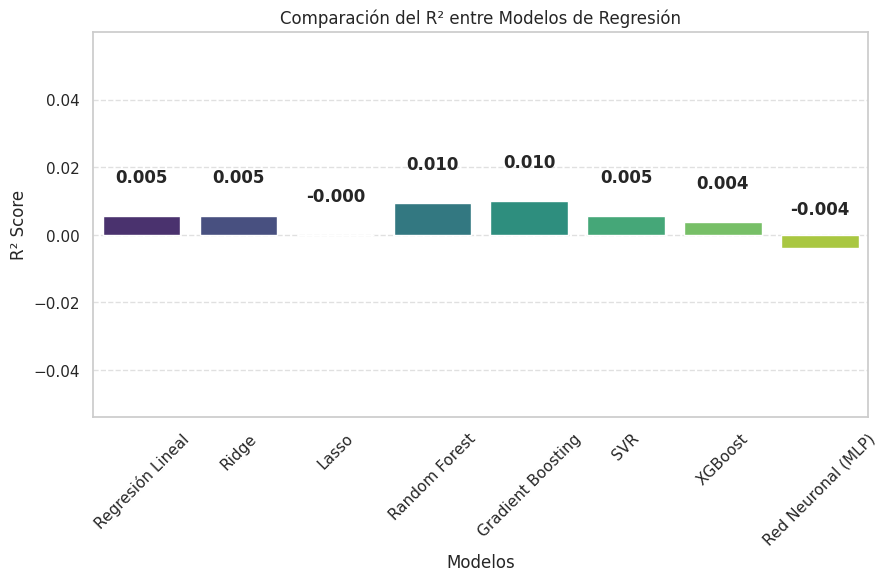

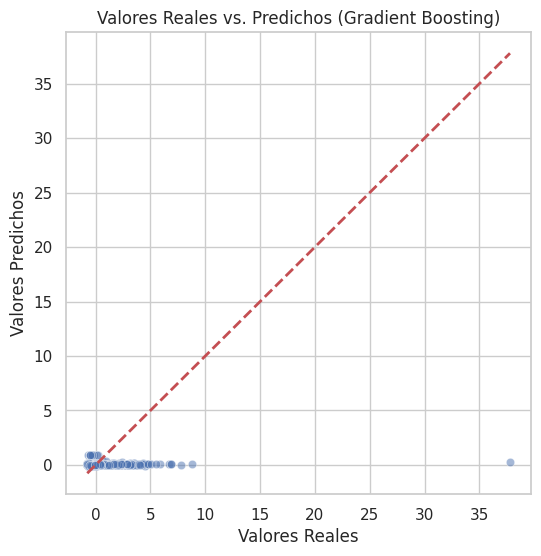

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Mejora en la visualización de la comparación de R²
plt.figure(figsize=(10, 5))
ax = sns.barplot(x=list(resultados.keys()), y=list(resultados.values()), palette='viridis')

# Agregar etiquetas de los valores en las barras
for index, value in enumerate(resultados.values()):
    ax.text(index, value + 0.01, f'{value:.3f}', ha='center', fontsize=12, fontweight='bold')

# Ajustar los límites del eje Y para resaltar diferencias
plt.ylim(min(resultados.values()) - 0.05, max(resultados.values()) + 0.05)

plt.xlabel('Modelos')
plt.ylabel('R² Score')
plt.title('Comparación del R² entre Modelos de Regresión')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()


# Evaluación del mejor modelo seleccionado
modelo_seleccionado = modelos[mejor_modelo]
y_pred_mejor = modelo_seleccionado.predict(X_test)

# Gráfico de dispersión entre valores reales y predichos
plt.figure(figsize=(6, 6))
#sns.scatterplot(x=y_test, y=y_pred_mejor, alpha=0.5)
sns.scatterplot(x=np.ravel(y_test), y=np.ravel(y_pred_mejor), alpha=0.5)

plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], '--r', linewidth=2)  # Línea de referencia
plt.xlabel('Valores Reales')
plt.ylabel('Valores Predichos')
plt.title(f'Valores Reales vs. Predichos ({mejor_modelo})')
plt.show()

# Histograma de errores (residuos)
errores = y_test - y_pred_mejor
plt.figure(figsize=(8, 5))
sns.histplot(errores, bins=20, kde=True, color='blue')
plt.xlabel('Error (y_real - y_predicho)')
plt.ylabel('Frecuencia')
plt.title(f'Distribución de Errores ({mejor_modelo})')
plt.show()